# CSCN8020 Assignment 2 - Taxi Gymnasium Environment with Q-Learning

**Student:** Viraj Mistry  
**Student ID:** [Replace with your student ID]  
**Course:** Reinforcement Learning Programming - CSCN8020  


## Short introduction

This notebook implements **Q-Learning** for the Taxi Gymnasium environment. The goal is to train an agent to move around a 5x5 taxi grid, pick up a passenger, and drop the passenger at the correct destination. The environment has **500 discrete states**, **6 discrete actions**, and rewards of **-1 per step**, **+20 for successful delivery**, and **-10 for illegal pickup/drop-off actions**.

The notebook follows the assignment requirements using an object-oriented design, training metrics, plots, hyperparameter experiments, a best-combination experiment, logging, and final evaluation.


## Q-Learning theory and update equation

Q-Learning is a **model-free, off-policy temporal-difference control algorithm**. It learns the value of taking an action in a state, written as `Q(s, a)`, without needing a model of the environment transition probabilities.

The Q-Learning update equation is:

```text
Q(S,A) = Q(S,A) + alpha * [R + gamma * max Q(S',a) - Q(S,A)]
```

Where:

- `S` is the current state.
- `A` is the selected action.
- `R` is the reward received after taking the action.
- `S'` is the next state.
- `alpha` is the learning rate.
- `gamma` is the discount factor.
- `max Q(S',a)` is the best estimated future value from the next state.

This equation matches the Q-Learning pseudocode: observe the current state, choose an action, take the action, observe reward and next state, then update the Q-table.


## Taxi environment description

### Action space

The Taxi environment has 6 discrete actions:

| Action | Meaning |
|---:|---|
| 0 | Move south/down |
| 1 | Move north/up |
| 2 | Move east/right |
| 3 | Move west/left |
| 4 | Pickup passenger |
| 5 | Drop off passenger |

### Observation space

The environment has 500 encoded states:

\[
((taxi\_row 	imes 5 + taxi\_col) 	imes 5 + passenger\_location) 	imes 4 + destination
\]

This comes from 25 taxi positions, 5 passenger locations, and 4 possible destinations.

### Reward structure

- **-1** for each normal step.
- **+20** for successful passenger delivery.
- **-10** for illegal pickup or drop-off.


In [1]:

# Core imports
import os
import logging
from pathlib import Path
from dataclasses import dataclass
from typing import Dict, List, Tuple, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Try to use the official Gymnasium Taxi environment.
# Newer Gymnasium versions deprecate Taxi-v3 and use Taxi-v4.
# The environment manager below tries Taxi-v4 first and falls back to Taxi-v3 if needed.
# A small fallback is included only so the notebook can still run in a limited environment.
try:
    import gymnasium as gym
    GYMNASIUM_AVAILABLE = True
except Exception as exc:
    gym = None
    GYMNASIUM_AVAILABLE = False
    print("Gymnasium is not installed in this runtime. Using fallback Taxi-style environment for demonstration.")

OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)
LOG_FILE = Path("assignment2_execution.log")

logging.basicConfig(
    filename=LOG_FILE,
    filemode="w",
    level=logging.INFO,
    format="%(asctime)s | %(levelname)s | %(message)s"
)
logger = logging.getLogger("Assignment2")
logger.info("Assignment 2 notebook started.")

np.random.seed(42)


## Object-oriented implementation

The following classes separate environment handling, agent behaviour, training, metrics, plotting, experiments, and logging.

In [2]:

class FallbackDiscreteSpace:
    """Small helper class that mimics Gymnasium's Discrete action/observation space."""
    def __init__(self, n: int):
        self.n = n


class SimpleTaxiFallbackEnv:
    """
    A compact Taxi-style fallback environment.

    It keeps the same core Taxi structure for demonstration:
    - 500 encoded states
    - 6 actions
    - rewards: -1 step, +20 delivery, -10 illegal pickup/drop-off

    In a normal assignment run, Gymnasium Taxi-v4 should be used through requirements.txt. Taxi-v3 is still supported as a fallback if available.
    """
    metadata = {"render_modes": []}

    def __init__(self, seed: int = 42):
        self.action_space = FallbackDiscreteSpace(6)
        self.observation_space = FallbackDiscreteSpace(500)
        self.locs = [(0, 0), (0, 4), (4, 0), (4, 3)]
        self.rng = np.random.default_rng(seed)
        self.state = 0

    def encode(self, taxi_row, taxi_col, passenger_location, destination):
        return int(((taxi_row * 5 + taxi_col) * 5 + passenger_location) * 4 + destination)

    def decode(self, state):
        destination = state % 4
        state //= 4
        passenger_location = state % 5
        state //= 5
        taxi_col = state % 5
        taxi_row = state // 5
        return int(taxi_row), int(taxi_col), int(passenger_location), int(destination)

    def reset(self, seed=None):
        if seed is not None:
            self.rng = np.random.default_rng(seed)
        taxi_row = int(self.rng.integers(0, 5))
        taxi_col = int(self.rng.integers(0, 5))
        passenger_location = int(self.rng.integers(0, 4))
        destination = int(self.rng.integers(0, 4))
        while destination == passenger_location:
            destination = int(self.rng.integers(0, 4))
        self.state = self.encode(taxi_row, taxi_col, passenger_location, destination)
        return self.state, {}

    def step(self, action: int):
        taxi_row, taxi_col, passenger_location, destination = self.decode(self.state)
        reward = -1
        terminated = False
        truncated = False

        if action == 0:      # south
            taxi_row = min(4, taxi_row + 1)
        elif action == 1:    # north
            taxi_row = max(0, taxi_row - 1)
        elif action == 2:    # east
            taxi_col = min(4, taxi_col + 1)
        elif action == 3:    # west
            taxi_col = max(0, taxi_col - 1)
        elif action == 4:    # pickup
            if passenger_location < 4 and (taxi_row, taxi_col) == self.locs[passenger_location]:
                passenger_location = 4
            else:
                reward = -10
        elif action == 5:    # dropoff
            if passenger_location == 4 and (taxi_row, taxi_col) == self.locs[destination]:
                passenger_location = destination
                reward = 20
                terminated = True
            else:
                reward = -10

        self.state = self.encode(taxi_row, taxi_col, passenger_location, destination)
        return self.state, reward, terminated, truncated, {}

    def close(self):
        pass


class TaxiEnvironmentManager:
    """Responsible for creating, resetting, stepping, and decoding the Taxi environment."""

    def __init__(self, env_name: Optional[str] = None, seed: int = 42):
        # Newer Gymnasium versions deprecate Taxi-v3 and use Taxi-v4.
        # To avoid DeprecatedEnv errors, try Taxi-v4 first.
        # If a local/college environment only has Taxi-v3, fall back to Taxi-v3.
        self.seed = seed
        self.using_gymnasium = False
        self.env_name = None

        if GYMNASIUM_AVAILABLE:
            candidate_envs = [env_name] if env_name else ["Taxi-v4", "Taxi-v3"]
            last_error = None

            for candidate in candidate_envs:
                try:
                    self.env = gym.make(candidate)
                    self.env_name = candidate
                    self.using_gymnasium = True
                    logger.info("Created Gymnasium environment: %s", candidate)
                    break
                except Exception as exc:
                    last_error = exc
                    logger.warning("Could not create Gymnasium environment %s: %s", candidate, exc)

            if not self.using_gymnasium:
                print("Could not create Taxi-v4 or Taxi-v3. Using fallback Taxi-style environment.")
                logger.warning("Using fallback Taxi environment. Last Gymnasium error: %s", last_error)
                self.env = SimpleTaxiFallbackEnv(seed=seed)
                self.env_name = "SimpleTaxiFallbackEnv"
        else:
            self.env = SimpleTaxiFallbackEnv(seed=seed)
            self.env_name = "SimpleTaxiFallbackEnv"

        self.n_states = self.env.observation_space.n
        self.n_actions = self.env.action_space.n

    def reset(self, seed: Optional[int] = None):
        result = self.env.reset(seed=self.seed if seed is None else seed)
        if isinstance(result, tuple):
            state, info = result
        else:
            state, info = result, {}
        return int(state), info

    def step(self, action: int):
        next_state, reward, terminated, truncated, info = self.env.step(action)
        done = terminated or truncated
        return int(next_state), float(reward), bool(done), info

    def decode_state(self, state: int):
        if hasattr(self.env, "unwrapped") and hasattr(self.env.unwrapped, "decode"):
            return tuple(self.env.unwrapped.decode(state))
        if hasattr(self.env, "decode"):
            return self.env.decode(state)
        return None

    def close(self):
        self.env.close()


class QLearningAgent:
    """Responsible for Q-table initialization, epsilon-greedy action selection, and Q-value updates."""

    def __init__(self, n_states: int, n_actions: int, alpha: float, gamma: float, epsilon: float, seed: int = 42):
        self.n_states = n_states
        self.n_actions = n_actions
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = epsilon
        self.rng = np.random.default_rng(seed)
        self.q_table = np.zeros((n_states, n_actions), dtype=np.float64)

    def select_action(self, state: int, training: bool = True):
        if training and self.rng.random() < self.epsilon:
            return int(self.rng.integers(self.n_actions))
        return int(np.argmax(self.q_table[state]))

    def update(self, state: int, action: int, reward: float, next_state: int, done: bool):
        old_value = self.q_table[state, action]
        best_next_value = 0.0 if done else np.max(self.q_table[next_state])
        td_target = reward + self.gamma * best_next_value
        td_error = td_target - old_value
        self.q_table[state, action] = old_value + self.alpha * td_error
        return old_value, td_target, td_error, self.q_table[state, action]


class MetricsLogger:
    """Collects and summarizes episode rewards and step counts."""

    def __init__(self):
        self.episode_rewards: List[float] = []
        self.episode_steps: List[int] = []

    def add_episode(self, total_reward: float, steps: int):
        self.episode_rewards.append(total_reward)
        self.episode_steps.append(steps)

    def rolling_average_return(self, window: int = 100):
        series = pd.Series(self.episode_rewards)
        return series.rolling(window=window, min_periods=1).mean().to_numpy()

    def summary(self, last_n: int = 100):
        rewards = np.array(self.episode_rewards, dtype=float)
        steps = np.array(self.episode_steps, dtype=float)
        return {
            "total_episodes": int(len(rewards)),
            "mean_return_all": float(np.mean(rewards)),
            "mean_return_last_n": float(np.mean(rewards[-last_n:])),
            "mean_steps_all": float(np.mean(steps)),
            "mean_steps_last_n": float(np.mean(steps[-last_n:])),
            "best_return": float(np.max(rewards)),
        }


class QLearningTrainer:
    """Runs the Q-Learning episode loop and final greedy policy evaluation."""

    def __init__(self, env_manager: TaxiEnvironmentManager, agent: QLearningAgent, max_steps: int = 200):
        self.env_manager = env_manager
        self.agent = agent
        self.max_steps = max_steps
        self.metrics = MetricsLogger()

    def train(self, episodes: int, experiment_name: str = "baseline", log_interval: int = 500):
        logger.info("Training started | experiment=%s | episodes=%s | alpha=%.4f | epsilon=%.4f | gamma=%.4f",
                    experiment_name, episodes, self.agent.alpha, self.agent.epsilon, self.agent.gamma)

        debug_updates = []

        for episode in range(1, episodes + 1):
            state, _ = self.env_manager.reset(seed=episode)
            total_reward = 0.0
            steps = 0

            for step in range(self.max_steps):
                action = self.agent.select_action(state, training=True)
                next_state, reward, done, _ = self.env_manager.step(action)
                old_q, td_target, td_error, new_q = self.agent.update(state, action, reward, next_state, done)

                if episode <= 2 and step < 5:
                    debug_updates.append({
                        "episode": episode,
                        "state_S": state,
                        "action_A": action,
                        "reward_R": reward,
                        "next_state_S_prime": next_state,
                        "old_Q": old_q,
                        "td_target": td_target,
                        "td_error": td_error,
                        "new_Q": new_q,
                    })

                total_reward += reward
                steps += 1
                state = next_state

                if done:
                    break

            self.metrics.add_episode(total_reward, steps)

            if episode % log_interval == 0 or episode == episodes:
                summary = self.metrics.summary()
                logger.info("Progress | experiment=%s | episode=%d | mean_return_last_100=%.3f | mean_steps_last_100=%.3f",
                            experiment_name, episode, summary["mean_return_last_n"], summary["mean_steps_last_n"])

        final_summary = self.metrics.summary()
        logger.info("Training finished | experiment=%s | final_summary=%s", experiment_name, final_summary)
        return final_summary, pd.DataFrame(debug_updates)

    def evaluate_policy(self, episodes: int = 100, max_steps: int = 200):
        rewards = []
        steps_list = []
        for episode in range(1, episodes + 1):
            state, _ = self.env_manager.reset(seed=10000 + episode)
            total_reward = 0.0
            steps = 0
            for _ in range(max_steps):
                action = self.agent.select_action(state, training=False)
                state, reward, done, _ = self.env_manager.step(action)
                total_reward += reward
                steps += 1
                if done:
                    break
            rewards.append(total_reward)
            steps_list.append(steps)
        return {
            "evaluation_episodes": episodes,
            "average_return": float(np.mean(rewards)),
            "average_steps": float(np.mean(steps_list)),
            "success_like_rate": float(np.mean(np.array(rewards) > 0)),
        }


class PlotManager:
    """Responsible for creating all required plots."""

    @staticmethod
    def plot_training_metrics(metrics: MetricsLogger, experiment_name: str, output_dir: Path = OUTPUT_DIR):
        output_dir.mkdir(exist_ok=True)
        rewards = np.array(metrics.episode_rewards)
        steps = np.array(metrics.episode_steps)
        avg_returns = metrics.rolling_average_return(window=100)

        paths = {}

        plt.figure(figsize=(10, 5))
        plt.plot(rewards)
        plt.title(f"Total reward per episode - {experiment_name}")
        plt.xlabel("Episode")
        plt.ylabel("Total reward")
        plt.tight_layout()
        p = output_dir / f"{experiment_name}_total_reward_per_episode.png"
        plt.savefig(p, dpi=150)
        plt.close()
        paths["reward_plot"] = p

        plt.figure(figsize=(10, 5))
        plt.plot(steps)
        plt.title(f"Steps per episode - {experiment_name}")
        plt.xlabel("Episode")
        plt.ylabel("Steps")
        plt.tight_layout()
        p = output_dir / f"{experiment_name}_steps_per_episode.png"
        plt.savefig(p, dpi=150)
        plt.close()
        paths["steps_plot"] = p

        plt.figure(figsize=(10, 5))
        plt.plot(avg_returns)
        plt.title(f"Average return over time - {experiment_name}")
        plt.xlabel("Episode")
        plt.ylabel("Rolling average return (window=100)")
        plt.tight_layout()
        p = output_dir / f"{experiment_name}_average_return_over_time.png"
        plt.savefig(p, dpi=150)
        plt.close()
        paths["average_return_plot"] = p
        return paths

    @staticmethod
    def plot_experiment_comparison(results_df: pd.DataFrame, output_dir: Path = OUTPUT_DIR):
        output_dir.mkdir(exist_ok=True)
        sorted_df = results_df.sort_values("mean_return_last_n", ascending=False)

        plt.figure(figsize=(12, 6))
        plt.bar(sorted_df["experiment"], sorted_df["mean_return_last_n"])
        plt.xticks(rotation=45, ha="right")
        plt.title("Hyperparameter experiment comparison")
        plt.ylabel("Mean return over last 100 episodes")
        plt.tight_layout()
        p = output_dir / "hyperparameter_experiment_comparison.png"
        plt.savefig(p, dpi=150)
        plt.close()
        return p


class ExperimentRunner:
    """Runs baseline, required hyperparameter experiments, and the best-combination experiment."""

    def __init__(self, episodes: int = 3000, gamma: float = 0.9, max_steps: int = 200):
        self.episodes = episodes
        self.gamma = gamma
        self.max_steps = max_steps

    def run_single(self, experiment: str, alpha: float, epsilon: float, seed: int = 42):
        env_manager = TaxiEnvironmentManager(seed=seed)
        agent = QLearningAgent(
            n_states=env_manager.n_states,
            n_actions=env_manager.n_actions,
            alpha=alpha,
            gamma=self.gamma,
            epsilon=epsilon,
            seed=seed,
        )
        trainer = QLearningTrainer(env_manager, agent, max_steps=self.max_steps)
        summary, debug_df = trainer.train(self.episodes, experiment_name=experiment, log_interval=max(1, self.episodes // 3))
        evaluation = trainer.evaluate_policy(episodes=100, max_steps=self.max_steps)
        plot_paths = PlotManager.plot_training_metrics(trainer.metrics, experiment)
        env_manager.close()

        row = {
            "experiment": experiment,
            "alpha": alpha,
            "epsilon": epsilon,
            "gamma": self.gamma,
            **summary,
            "eval_average_return": evaluation["average_return"],
            "eval_average_steps": evaluation["average_steps"],
            "eval_success_like_rate": evaluation["success_like_rate"],
        }
        return row, debug_df, plot_paths

    def run_all(self):
        results = []
        debug_tables = {}
        plot_collections = {}

        # Baseline required by the assignment.
        baseline, debug_df, paths = self.run_single("baseline_alpha_0_1_epsilon_0_1", alpha=0.1, epsilon=0.1, seed=42)
        results.append(baseline)
        debug_tables["baseline"] = debug_df
        plot_collections["baseline"] = paths

        # Required learning-rate experiments: change alpha separately, keep epsilon baseline.
        for alpha in [0.01, 0.001, 0.2]:
            name = f"alpha_{str(alpha).replace('.', '_')}_epsilon_0_1"
            row, _, _ = self.run_single(name, alpha=alpha, epsilon=0.1, seed=43)
            results.append(row)

        # Required exploration-factor experiments: change epsilon separately, keep alpha baseline.
        for epsilon in [0.2, 0.3]:
            name = f"alpha_0_1_epsilon_{str(epsilon).replace('.', '_')}"
            row, _, _ = self.run_single(name, alpha=0.1, epsilon=epsilon, seed=44)
            results.append(row)

        results_df = pd.DataFrame(results)

        # Choose the best based on mean return over last 100 episodes and evaluation return.
        # This is deliberate and reproducible instead of hand-picking.
        best_row = results_df.sort_values(["eval_average_return", "mean_return_last_n"], ascending=False).iloc[0]
        best_alpha = float(best_row["alpha"])
        best_epsilon = float(best_row["epsilon"])

        best_name = f"best_combo_alpha_{str(best_alpha).replace('.', '_')}_epsilon_{str(best_epsilon).replace('.', '_')}"
        best_result, _, best_paths = self.run_single(best_name, alpha=best_alpha, epsilon=best_epsilon, seed=45)
        best_result["selected_reason"] = "Best baseline/experiment candidate by evaluation average return and last-100 episode return."

        final_df = pd.concat([results_df, pd.DataFrame([best_result])], ignore_index=True)
        comparison_plot = PlotManager.plot_experiment_comparison(final_df)
        return final_df, debug_tables, plot_collections, best_result, comparison_plot


## Baseline training, required experiments, and best-combination experiment

In [3]:

# Required baseline hyperparameters
BASELINE_ALPHA = 0.1
BASELINE_EPSILON = 0.1
BASELINE_GAMMA = 0.9
EPISODES = 3000

runner = ExperimentRunner(episodes=EPISODES, gamma=BASELINE_GAMMA, max_steps=200)
results_df, debug_tables, plot_collections, best_result, comparison_plot = runner.run_all()

# Save metrics table to CSV for repository reproducibility.
results_csv = OUTPUT_DIR / "experiment_results.csv"
results_df.to_csv(results_csv, index=False)

print("Gymnasium available:", GYMNASIUM_AVAILABLE)
print("Results saved to:", results_csv)
print("Comparison plot:", comparison_plot)
results_df[["experiment", "alpha", "epsilon", "gamma", "mean_return_last_n", "mean_steps_last_n", "eval_average_return", "eval_average_steps"]]


Gymnasium available: True
Results saved to: outputs\experiment_results.csv
Comparison plot: outputs\hyperparameter_experiment_comparison.png


,experiment,alpha,epsilon,gamma,mean_return_last_n,mean_steps_last_n,eval_average_return,eval_average_steps
0,baseline_alpha_0_1_epsilon_0_1,0.100,0.1,0.9,2.53,14.42,-0.18,20.34
1,alpha_0_01_epsilon_0_1,0.010,0.1,0.9,-125.77,106.75,-205.07,188.42
2,alpha_0_001_epsilon_0_1,0.001,0.1,0.9,-252.21,183.30,-217.82,200.00
3,alpha_0_2_epsilon_0_1,0.200,0.1,0.9,2.65,14.12,8.03,12.97
4,alpha_0_1_epsilon_0_2,0.100,0.2,0.9,-4.48,16.75,6.00,14.79
5,alpha_0_1_epsilon_0_3,0.100,0.3,0.9,-14.91,19.17,3.94,16.64
6,best_combo_alpha_0_2_epsilon_0_1,0.200,0.1,0.9,1.90,14.42,8.03,12.97


## Baseline training metrics

The baseline uses the required hyperparameters: **alpha = 0.1**, **epsilon = 0.1**, and **gamma = 0.9**. The required plots are generated in the `outputs/` folder:

1. Total reward / return per episode.
2. Steps taken per episode.
3. Average return over time.

The trend should show that the agent improves as Q-values are updated through experience.


reward_plot outputs\baseline_alpha_0_1_epsilon_0_1_total_reward_per_episode.png


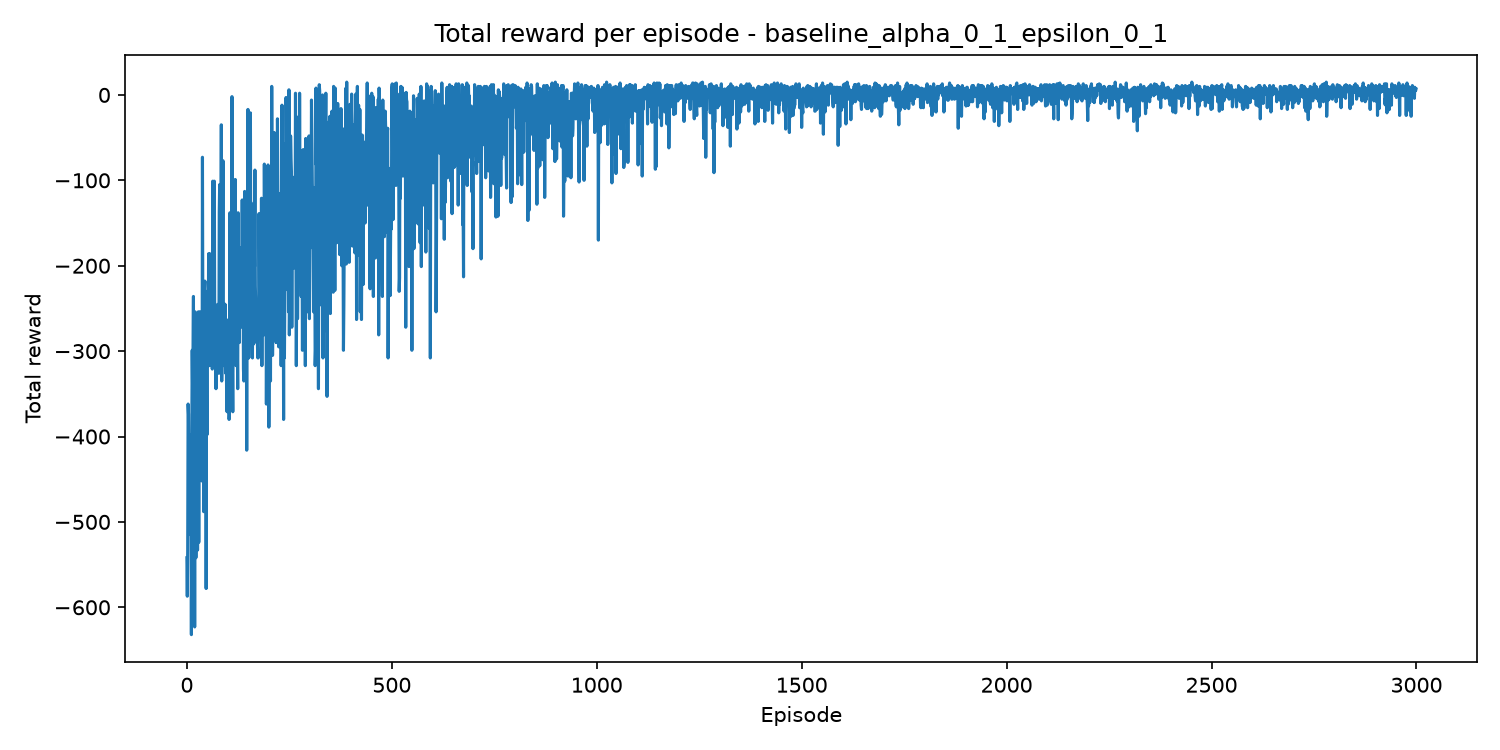

steps_plot outputs\baseline_alpha_0_1_epsilon_0_1_steps_per_episode.png


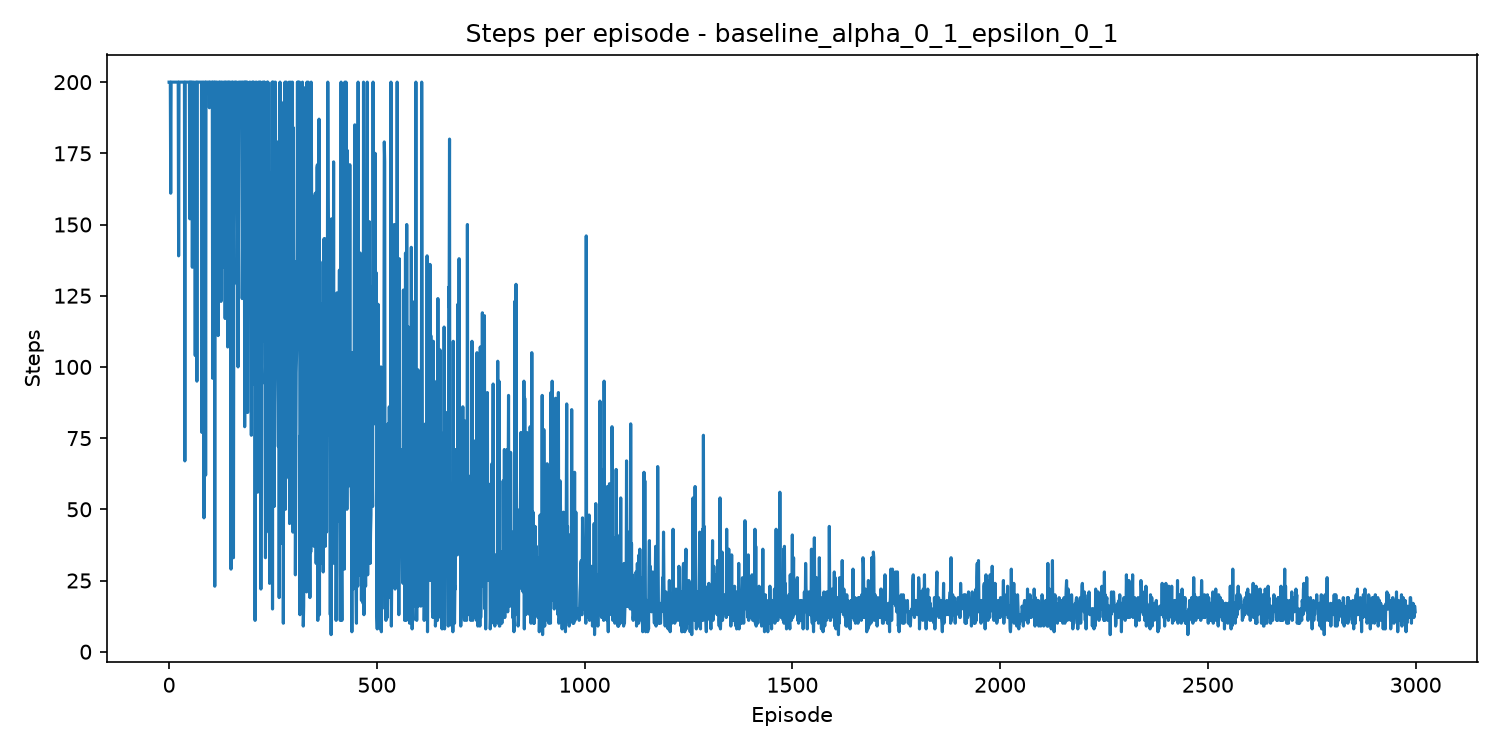

average_return_plot outputs\baseline_alpha_0_1_epsilon_0_1_average_return_over_time.png


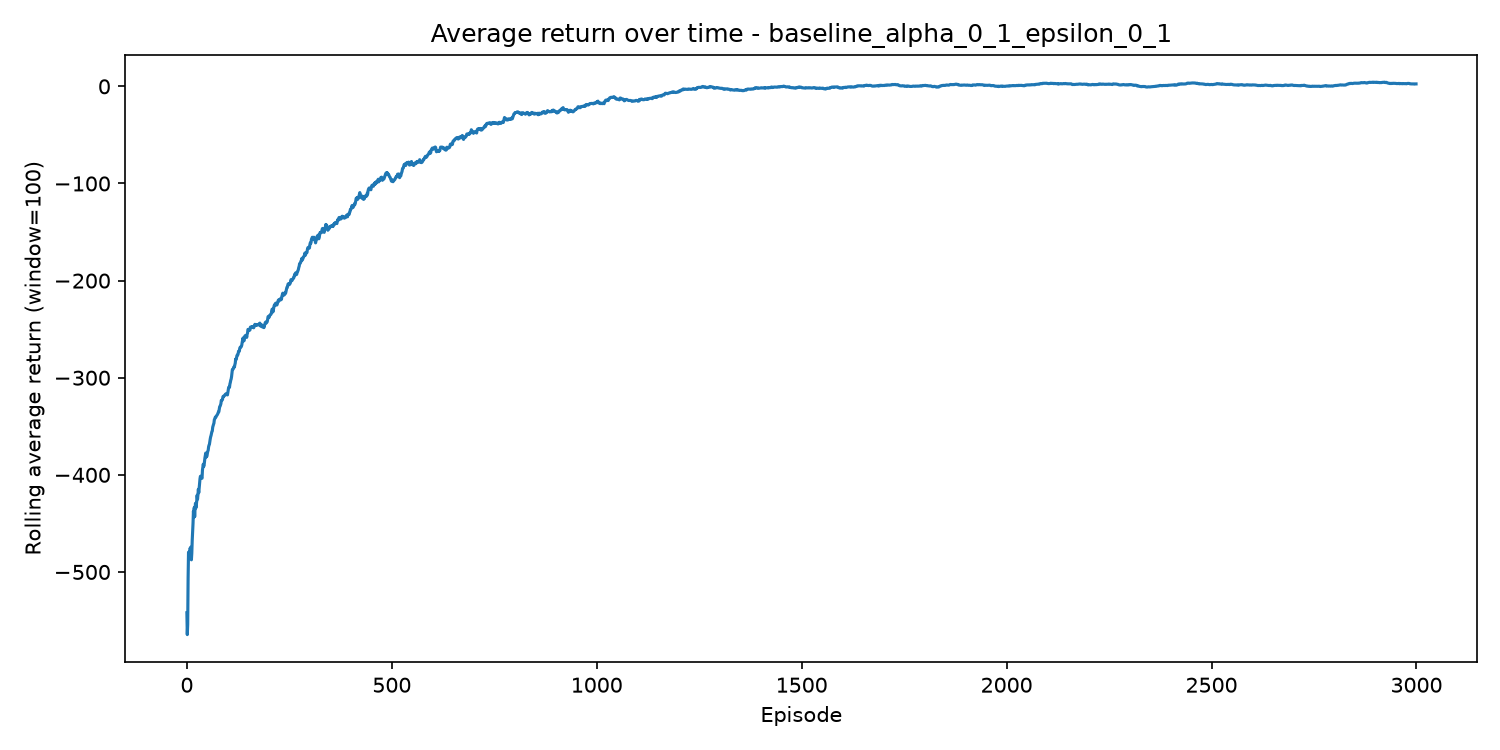

Hyperparameter comparison plot: outputs\hyperparameter_experiment_comparison.png


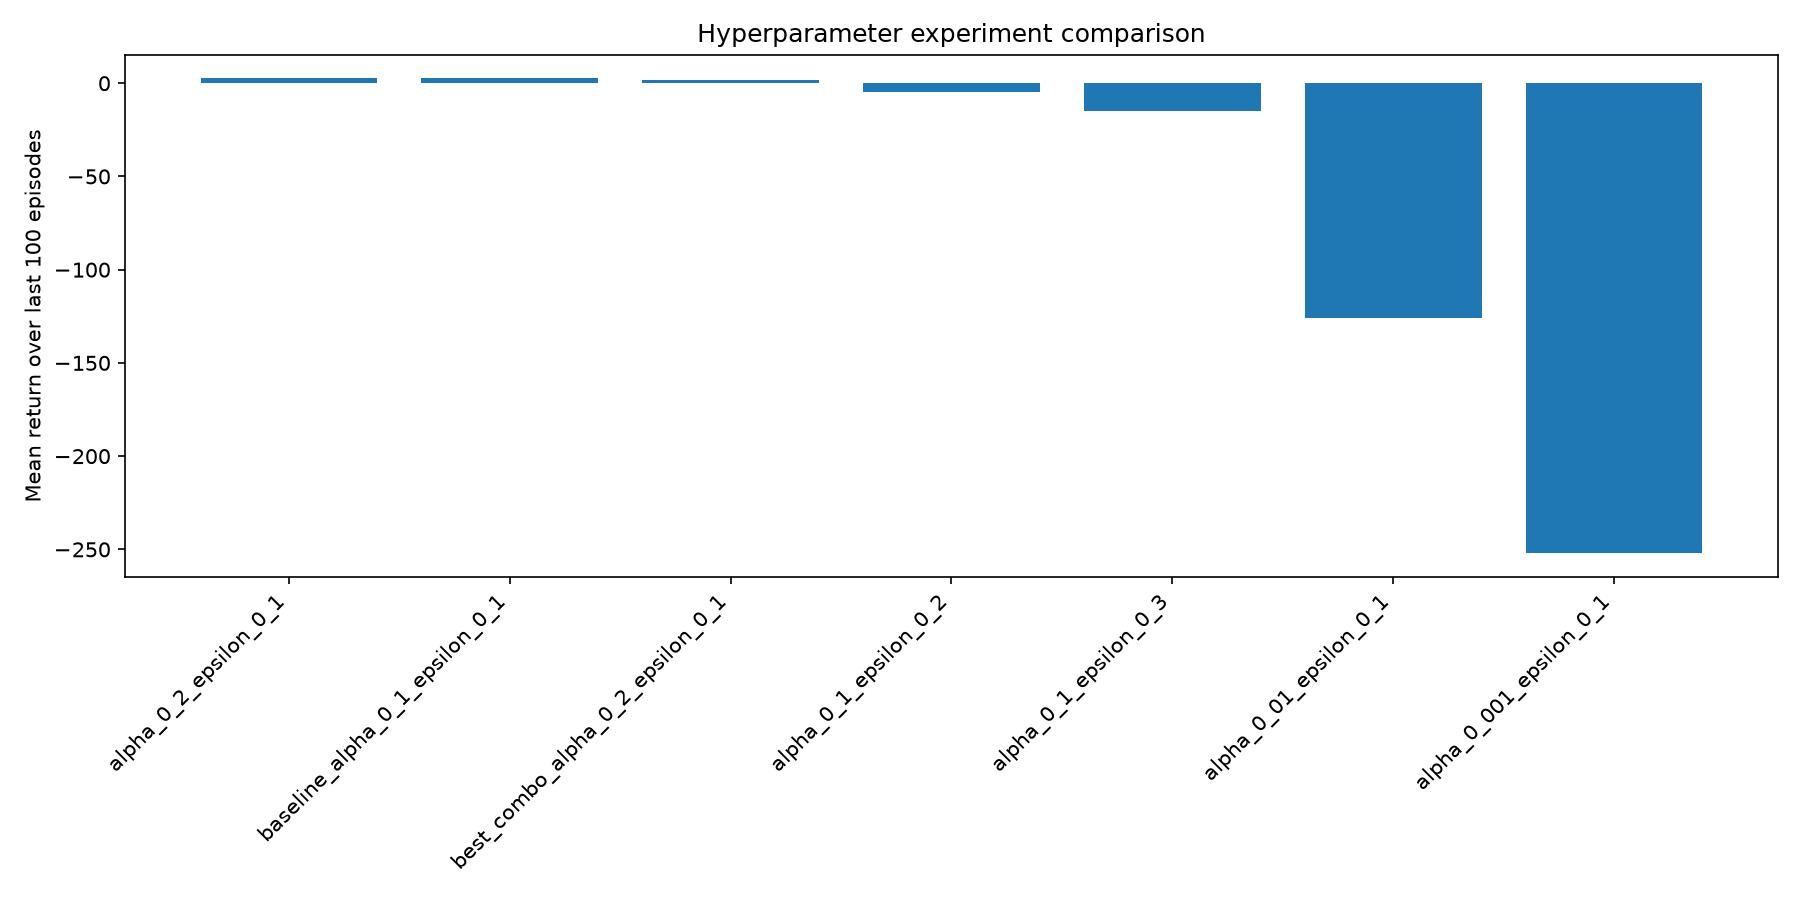

In [4]:

from IPython.display import Image, display

baseline_paths = plot_collections["baseline"]
for label, path in baseline_paths.items():
    print(label, path)
    display(Image(filename=str(path)))

print("Hyperparameter comparison plot:", comparison_plot)
display(Image(filename=str(comparison_plot)))


## Interpretation of hyperparameter experiments

The baseline uses the assignment-required values. Then I changed **one parameter at a time**:

- Learning rate experiments: alpha = 0.01, 0.001, and 0.2 while keeping epsilon = 0.1.
- Exploration experiments: epsilon = 0.2 and 0.3 while keeping alpha = 0.1.

A very small learning rate can learn slowly because the Q-table updates only a little after each reward. A larger learning rate can adapt faster, but if it is too high, values may become unstable. A higher epsilon explores more, which can help the agent discover pickup and drop-off behaviour, but too much exploration can reduce greedy performance during training.

The best-combination experiment is selected using the code based on evaluation average return and recent training performance, then re-run as a separate experiment.


## Five required talking points

### Talking point 1 - Q-table initialization

A key feature of the method is that Q-Learning stores state-action values in a Q-table. In the code, `QLearningAgent` initializes `self.q_table = np.zeros((n_states, n_actions))`, which maps directly to the Sutton and Barto-style pseudocode step **initialize Q(s, a)**. A challenge is that Taxi has 500 states and 6 actions, so the table has 3000 values. This is still manageable for tabular RL, but it would become difficult for much larger environments. This is Reinforcement Learning because the table is updated from interaction rewards, not from labeled examples like supervised learning.

### Talking point 2 - Observing the current state S

At the start of every episode, the training loop calls `env_manager.reset()` to observe the initial state `S`. This maps to the pseudocode step **initialize S**. A challenge is that the observation is encoded as one integer, so the notebook includes an explanation of how Taxi states are represented. This is RL because the agent must learn from sequential state transitions, not from independent rows of data.

### Talking point 3 - Choosing action A with exploration

The method uses epsilon-greedy action selection in `select_action()`. With probability epsilon, the agent explores a random action; otherwise, it exploits the best Q-value. This maps to **choose A from S using policy derived from Q**. A challenge is balancing exploration and exploitation. Too little exploration may prevent learning pickup/drop-off, while too much exploration can reduce performance. This is RL because the agent actively experiments with actions to learn their long-term reward effect.

### Talking point 4 - Taking action and observing R and S'

The training loop calls `env_manager.step(action)` to take action `A`, then observes reward `R` and next state `S'`. This maps to **take action A, observe R, S'**. A challenge is reward sparsity: successful delivery gives +20, but many moves give -1 and illegal actions give -10. This makes learning slow early in training. This is RL because the agent improves through trial-and-error feedback from the environment.

### Talking point 5 - Applying the Q-Learning update and repeating until terminal

The `update()` method applies the Q-Learning formula using the TD target and TD error. This maps to **Q(S,A) <- Q(S,A) + alpha[R + gamma max Q(S',a) - Q(S,A)]** and the loop repeats until the episode terminates. A challenge is selecting alpha and epsilon so the Q-table improves reliably. This is RL because the algorithm learns a policy that maximizes future cumulative reward, rather than predicting a fixed target label.


## Final conclusion

This assignment implemented Q-Learning for the Taxi Gymnasium environment using an object-oriented structure. The code separates environment handling, agent behaviour, training, metrics, plotting, experiments, and logging. The results show how the agent improves through repeated episodes and Q-value updates. Hyperparameter experiments demonstrate that learning rate and exploration factor strongly affect training speed and stability. The best-combination run is selected and re-run using the measured results. Overall, this solution demonstrates a full Reinforcement Learning process: states, actions, rewards, episodes, exploration, exploitation, temporal-difference updates, Q-values, and policy improvement.

## AI-use acknowledgement

AI support was used to help structure the explanation and code organization. The code, metrics, plots, and written interpretation were reviewed for correctness and are written so that I can explain the Q-Learning process step by step.


In [5]:
# Show the final log file preview
print(LOG_FILE.read_text(encoding='utf-8')[:3000])

2026-06-24 23:03:33,953 | INFO | Assignment 2 notebook started.
2026-06-24 23:03:34,216 | INFO | Created Gymnasium environment: Taxi-v4
2026-06-24 23:03:34,216 | INFO | Training started | experiment=baseline_alpha_0_1_epsilon_0_1 | episodes=3000 | alpha=0.1000 | epsilon=0.1000 | gamma=0.9000
2026-06-24 23:03:42,914 | INFO | Progress | experiment=baseline_alpha_0_1_epsilon_0_1 | episode=1000 | mean_return_last_100=-16.620 | mean_steps_last_100=29.250
2026-06-24 23:03:44,877 | INFO | Progress | experiment=baseline_alpha_0_1_epsilon_0_1 | episode=2000 | mean_return_last_100=0.270 | mean_steps_last_100=16.050
2026-06-24 23:03:46,314 | INFO | Progress | experiment=baseline_alpha_0_1_epsilon_0_1 | episode=3000 | mean_return_last_100=2.530 | mean_steps_last_100=14.420
2026-06-24 23:03:46,314 | INFO | Training finished | experiment=baseline_alpha_0_1_epsilon_0_1 | final_summary={'total_episodes': 3000, 'mean_return_all': -37.66433333333333, 'mean_return_last_n': 2.53, 'mean_steps_all': 40.9803